# Atividade de series temporais

Essa atividade é para um fim didático de estudar series temporais por completo, classifica-las e aprofundar o conhecimento

## Carregando a base

#### Base que guarda o preço de casas vendidas no periodo de 2007-2019

In [251]:
import kagglehub

path_sales = kagglehub.dataset_download("htagholdings/property-sales")

print("Path to dataset files:", path_sales)

Path to dataset files: C:\Users\miguelaraujo-ieg\.cache\kagglehub\datasets\htagholdings\property-sales\versions\3


#### Base que guarda o consumo de energia de casas no periodo de 2006 a 2010

In [252]:
path_eletricpower = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", path_eletricpower)

Path to dataset files: C:\Users\miguelaraujo-ieg\.cache\kagglehub\datasets\uciml\electric-power-consumption-data-set\versions\1


In [253]:
import pandas as pd
import os
df_property_sales = pd.read_csv(os.path.join(path_sales, "raw_sales.csv"))
df_electric_power = pd.read_csv(os.path.join(path_eletricpower, "household_power_consumption.txt"), sep=";")

C:\Users\miguelaraujo-ieg\AppData\Local\Temp\ipykernel_24884\2262707762.py:4: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_electric_power = pd.read_csv(os.path.join(path_eletricpower, "household_power_consumption.txt"), sep=";")


In [254]:
df_electric_power

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


## Transformando em series temporais - Granularidade, Limpeza e entendimento

In [255]:
serie_property_sales = df_property_sales[["price","datesold"]]

In [256]:

serie_property_sales['datesold'] = pd.to_datetime(
    serie_property_sales['datesold'],
    errors='coerce'
)

serie_property_sales = serie_property_sales.dropna(subset=['datesold'])

serie_property_sales = serie_property_sales.set_index('datesold')

serie_property_sales = serie_property_sales.sort_index()

serie_property_sales = serie_property_sales.resample('MS').mean()

In [257]:
serie_property_sales

,price
datesold,
2007-02-01,407500.000000
2007-03-01,339333.333333
2007-04-01,798000.000000
2007-05-01,339500.000000
2007-06-01,520333.333333
...,...
2019-03-01,651666.737288
2019-04-01,655325.561321
2019-05-01,641491.136364


In [258]:
df_electric_power

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


In [259]:
df_electric_power['datetime'] = pd.to_datetime(
    df_electric_power['Date'] + ' ' + df_electric_power['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df_electric_power = df_electric_power.set_index('datetime')
df_electric_power

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2010-11-26 20:58:00,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0


In [260]:
serie_electric_power = df_electric_power['Global_active_power']
serie_electric_power

datetime
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
                       ...  
2010-11-26 20:58:00    0.946
2010-11-26 20:59:00    0.944
2010-11-26 21:00:00    0.938
2010-11-26 21:01:00    0.934
2010-11-26 21:02:00    0.932
Name: Global_active_power, Length: 2075259, dtype: object

In [261]:
serie_electric_power = pd.Series(serie_electric_power)
serie_electric_power = pd.to_numeric(serie_electric_power, errors='coerce')
serie_electric_power = serie_electric_power.dropna()
serie_electric_power = serie_electric_power.resample('MS').mean()
serie_electric_power

datetime
2006-12-01    1.901295
2007-01-01    1.546034
2007-02-01    1.401084
2007-03-01    1.318627
2007-04-01    0.891189
2007-05-01    0.985862
2007-06-01    0.826814
2007-07-01    0.667367
2007-08-01    0.764186
2007-09-01    0.969318
2007-10-01    1.103911
2007-11-01    1.294473
2007-12-01    1.626474
2008-01-01    1.459920
2008-02-01    1.181384
2008-03-01    1.245337
2008-04-01    1.115972
2008-05-01    1.024281
2008-06-01    0.994096
2008-07-01    0.794781
2008-08-01    0.276488
2008-09-01    0.987680
2008-10-01    1.136768
2008-11-01    1.387066
2008-12-01    1.275189
2009-01-01    1.410202
2009-02-01    1.247568
2009-03-01    1.226735
2009-04-01    1.140690
2009-05-01    1.012856
2009-06-01    0.840756
2009-07-01    0.618121
2009-08-01    0.664619
2009-09-01    0.986841
2009-10-01    1.144486
2009-11-01    1.274743
2009-12-01    1.364421
2010-01-01    1.430525
2010-02-01    1.375855
2010-03-01    1.130075
2010-04-01    1.027295
2010-05-01    1.095284
2010-06-01    0.969615
20

In [262]:
serie_property_sales = pd.Series(serie_property_sales['price'])
serie_property_sales

datesold
2007-02-01    407500.000000
2007-03-01    339333.333333
2007-04-01    798000.000000
2007-05-01    339500.000000
2007-06-01    520333.333333
                  ...      
2019-03-01    651666.737288
2019-04-01    655325.561321
2019-05-01    641491.136364
2019-06-01    703275.396825
2019-07-01    583192.056000
Freq: MS, Name: price, Length: 150, dtype: float64

## Estruturando as estacionariedade ou não das series

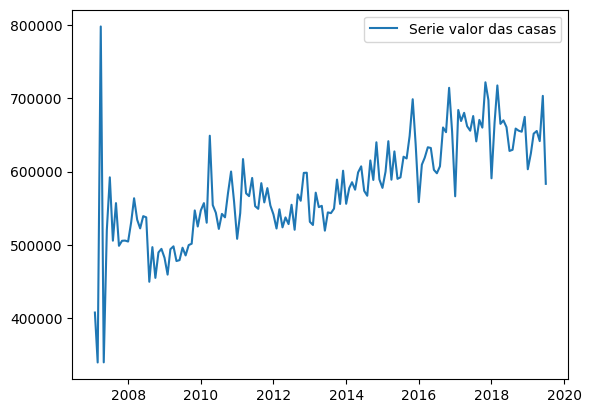

In [263]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(serie_property_sales, label='Serie valor das casas')
ax.legend()
plt.show()

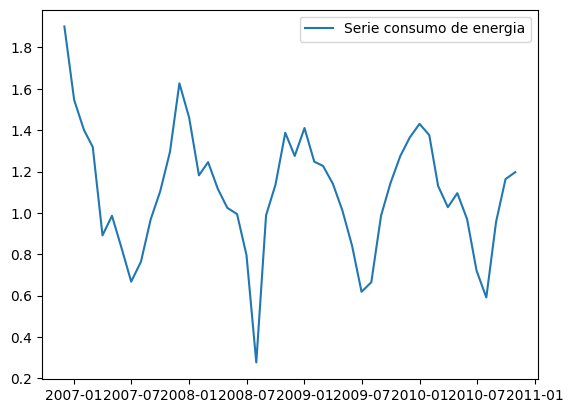

In [264]:
fig, ax = plt.subplots()
ax.plot(serie_electric_power, label='Serie consumo de energia')
ax.legend()
plt.show()


#### Plotando grafico acf (autorrelation) para verficar a estacionariedade das series

valor das propriedades

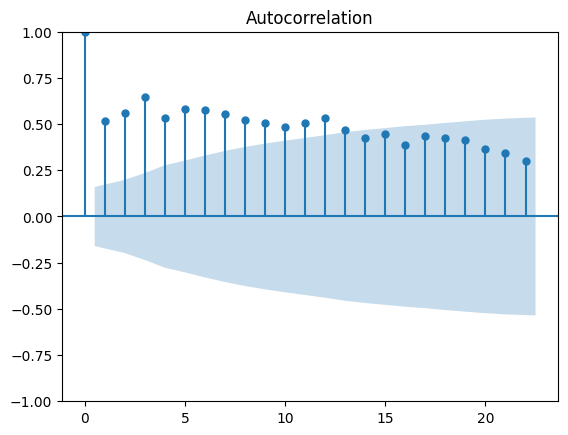

In [265]:
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots()
plot_acf(serie_property_sales, ax=ax)
plt.show()

consumo de energia

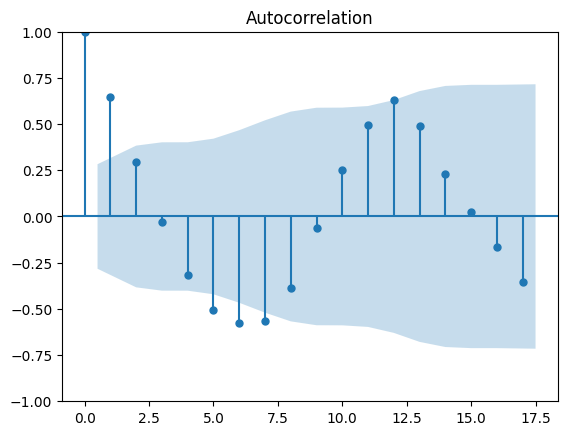

In [266]:
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots()
plot_acf(serie_electric_power, ax=ax)
plt.show()

#### Testes ADF nas series

##### Se p-value < 0.05 → estacionária ✅
##### Se p-value > 0.05 → NÃO estacionária ❌

valor das propriedades

In [267]:
from statsmodels.tsa.stattools import adfuller

print('ADF Statistic: %f' % adfuller(serie_property_sales)[0])
print('p-value: %f' % adfuller(serie_property_sales)[1])
print('Critical Values:')
for key, value in adfuller(serie_property_sales)[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -0.660214
p-value: 0.856788
Critical Values:
	1%: -3.479
	5%: -2.883
	10%: -2.578


#### A serie do valor das propriedades é NÃO ESTACIONARIA 

consumo de energia

In [268]:
from statsmodels.tsa.stattools import adfuller

print('ADF Statistic: %f' % adfuller(serie_electric_power)[0])
print('p-value: %f' % adfuller(serie_electric_power)[1])
print('Critical Values:')
for key, value in adfuller(serie_electric_power)[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.897270
p-value: 0.000035
Critical Values:
	1%: -3.616
	5%: -2.941
	10%: -2.609


#### A serie de consumo de energia é ESTACIONARIA

### Fazendo Modelo nas séries estacionarias

#### alguns metodos para ajudar no processo do modelo

In [283]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def train_test_split_ts(serie, train_size=0.9):
    split = int(len(serie) * train_size)
    train = serie[:split]
    test = serie[split:]
    return train, test

def train_model(train, lag):
    model = AutoReg(train, lags=lag).fit()
    return model

def evaluate(model, train, test):
    preds = model.predict(start=len(train), end=len(train)+len(test)-1)
    
    mae = mean_absolute_error(test, preds)
    rmse = np.sqrt(mean_squared_error(test, preds))
    
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")

def find_best_lag(train, test, max_lag=50):
    best_lag = None
    best_error = float('inf')
    
    for lag in range(1, max_lag + 1):
        try:
            model = AutoReg(train, lags=lag).fit()
            preds = model.predict(start=len(train), end=len(train)+len(test)-1)
            
            error = mean_squared_error(test, preds)
            
            if error < best_error:
                best_error = error
                best_lag = lag
                
        except:
            continue
    
    print(f"Melhor lag: {best_lag}")
    return best_lag

##### Pipeline - Consumo de energia

In [284]:
def run_pipeline(serie):    
    train, test = train_test_split_ts(serie)
    
    best_lag = find_best_lag(train, test)
    
    model = train_model(train, best_lag)
    
    preds = evaluate(model, train, test)
    
    return model, preds

model_eletric_power, preds_eletric_power = run_pipeline(serie_electric_power)

Melhor lag: 13
MAE: 0.04941246615911945
RMSE: 0.053452934272509287


c:\Users\miguelaraujo-ieg\OneDrive - Instituto J&F\3°ANO\Séries Temporais\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


#### 